In [1]:
import tensorflow as tf
from tensorflow.keras import models,layers
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
desired_classes = [                # taking only potato images
    'Potato___Early_blight',
    'Potato___healthy',
    'Potato___Late_blight'
]

In [3]:
# this will help load thee dataset in batches instead of full in RAM 
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    class_names = desired_classes,
    shuffle = True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [4]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']

In [5]:
len(dataset)

68

In [6]:
for image_batch , label_batch in dataset.take(1):
    print(image_batch.shape)
    print(image_batch[0].numpy())


(32, 256, 256, 3)
[[[202. 204. 216.]
  [174. 176. 188.]
  [207. 209. 221.]
  ...
  [150. 151. 169.]
  [176. 177. 195.]
  [139. 140. 158.]]

 [[191. 193. 205.]
  [178. 180. 192.]
  [218. 220. 232.]
  ...
  [141. 142. 160.]
  [169. 170. 188.]
  [170. 171. 189.]]

 [[186. 188. 200.]
  [174. 176. 188.]
  [200. 202. 214.]
  ...
  [154. 155. 173.]
  [156. 157. 175.]
  [168. 169. 187.]]

 ...

 [[112. 110. 124.]
  [122. 120. 134.]
  [146. 144. 158.]
  ...
  [107. 108. 128.]
  [120. 121. 141.]
  [111. 112. 132.]]

 [[131. 129. 143.]
  [128. 126. 140.]
  [ 91.  89. 103.]
  ...
  [108. 109. 129.]
  [111. 112. 132.]
  [126. 127. 147.]]

 [[123. 121. 135.]
  [122. 120. 134.]
  [132. 130. 144.]
  ...
  [122. 123. 143.]
  [131. 132. 152.]
  [102. 103. 123.]]]


(32, 256, 256, 3)


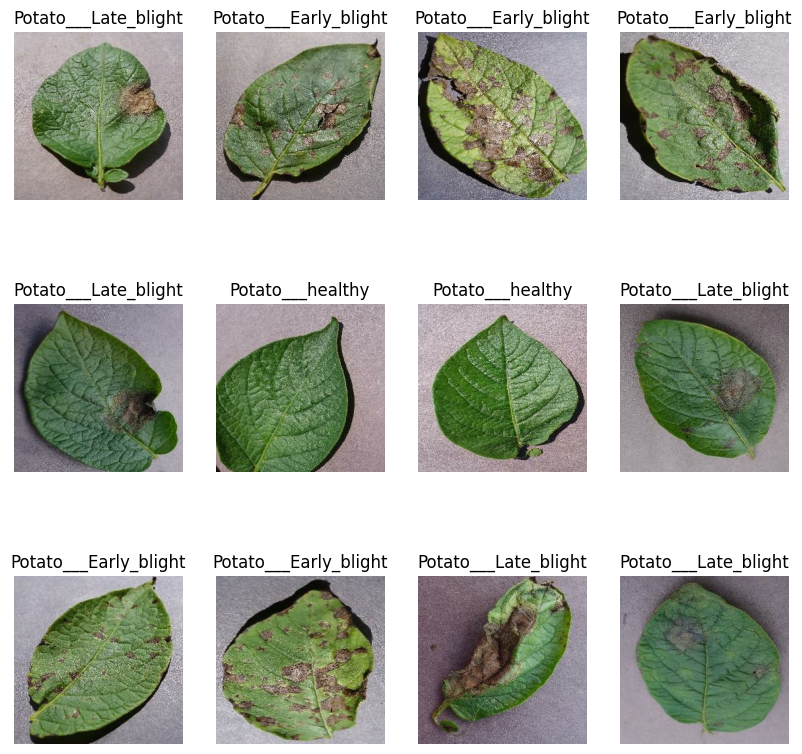

In [7]:
plt.figure(figsize=(10,10))
for image_batch , label_batch in dataset.take(1):
    print(image_batch.shape)
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

80% --> training dataset <br>
10%-10% --> val and test dataset

In [8]:
# take function will only take frist n traning data
def get_dataset_partitions(ds,train=0.8,val=0.1,test=0.1,shuffle=True,shuffle_size=10000):

    ds_size = len(dataset)
    train_size = int(ds_size*train)
    val_size = int(ds_size*val)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds,val_ds,test_ds

In [9]:
train_ds,val_ds,test_ds = get_dataset_partitions(dataset)

In [10]:
len(train_ds),len(val_ds),len(test_ds)

(54, 6, 8)

cache(), shuffle(), and prefetch() are TensorFlow dataset optimization functions used to speed up training and improve model performance. cache() stores the dataset in memory after the first pass so that images don't need to be loaded from disk repeatedly in every epoch. shuffle(1000) randomly mixes the training samples using a buffer of 1000 images, which helps the model generalize better and prevents it from learning patterns based on data order. prefetch(tf.data.AUTOTUNE) prepares the next batch of data while the current batch is being processed by the CPU/GPU, reducing idle time and making training faster. Together, they create an efficient input pipeline: cache the data, shuffle it, and load future batches in advance.

In [11]:
train_ds = train_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

In [12]:
# preprocessing the image size and scale
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    tf.keras.layers.Rescaling(1./255)
])

# data augmentation here


In [13]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2)
])

## MODELLING

In [14]:
n_classes = 3
model = models.Sequential([
    resize_and_rescale,
    data_aug,
    layers.Conv2D(32,(3,3),activation='relu',input_shape = (IMAGE_SIZE,IMAGE_SIZE,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(64, kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(64, kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(64, kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),

    layers.Flatten(),

    layers.Dense(64,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(n_classes,activation='softmax')
    
])
# model = models.Sequential([
#     resize_and_rescale,
#     data_aug,

#     layers.Conv2D(32, (3,3), activation='relu', input_shape=(BATCH_SIZE,IMAGE_SIZE, IMAGE_SIZE, 3)),
#     layers.MaxPooling2D((2,2)),

#     layers.Conv2D(64, (3,3), activation='relu'),
#     layers.MaxPooling2D((2,2)),

#     layers.Conv2D(128, (3,3), activation='relu'),
#     layers.MaxPooling2D((2,2)),

#     layers.Flatten(),

#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.5),

#     layers.Dense(n_classes, activation='softmax')
# ])

model.build(input_shape = (BATCH_SIZE,IMAGE_SIZE, IMAGE_SIZE, 3))

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 2304)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 277,891 (1.06 MB)

 Trainable params: 277,891 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [17]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint -- > it saves the model automatically during training, usually when it performs best on validation data.

So instead of only getting the final model after training, you also get the best version seen so far.

In [18]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(  
    "new_best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [19]:
history = model.fit(
    train_ds,
    epochs = 10,
    batch_size = BATCH_SIZE,
    verbose =1,
    validation_data = val_ds,
    callbacks = [early_stopping,checkpoint]
    
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.5388 - loss: 0.8673 - val_accuracy: 0.5938 - val_loss: 0.8342
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.7749 - loss: 0.5130 - val_accuracy: 0.8958 - val_loss: 0.3252
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.8241 - loss: 0.4735 - val_accuracy: 0.9323 - val_loss: 0.2352
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.8472 - loss: 0.3767 - val_accuracy: 0.8385 - val_loss: 0.3745
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 316s 6s/step - accuracy: 0.8669 - loss: 0.3220 - val_accuracy: 0.9167 - val_loss: 0.2159
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 237s 4s/step - accuracy: 0.8686 - loss: 0.3097 - val_accuracy: 0.8021 - val_loss: 0.4301
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 188s 4s/step - accuracy: 0.8843 - loss: 0.2774 - val_accuracy: 0.8333 - val_loss: 0.5292
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.8657 - loss: 0.3363 - val_accuracy: 0.9010 - v

In [20]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

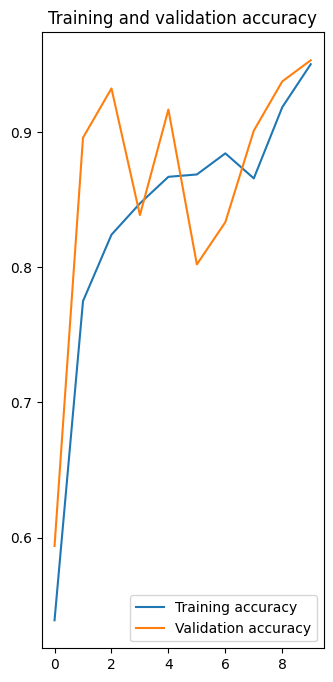

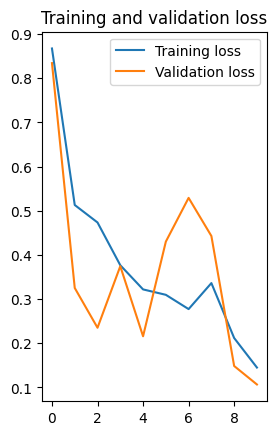

In [21]:
plt.figure(figsize = (8,8))
plt.subplot(1,2,1)
plt.plot(range(10),acc,label = 'Training accuracy')
plt.plot(range(10),val_acc,label = 'Validation accuracy')
plt.legend(loc='lower right')
plt.title('Training and validation accuracy')
plt.show()

plt.subplot(1,2,1)
plt.plot(range(10),loss,label = 'Training loss')
plt.plot(range(10),val_loss,label = 'Validation loss')
plt.legend(loc='upper right')
plt.title('Training and validation loss')
plt.show()


# prediction

first image to predict
actual label: Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
predicted label: Potato___Early_blight


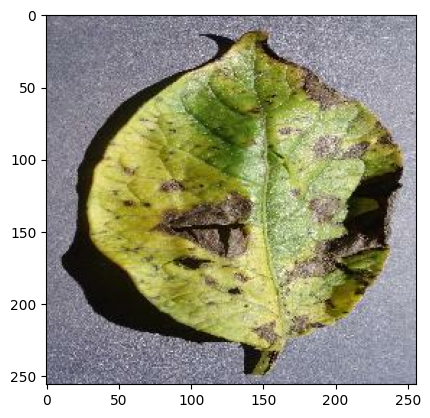

In [22]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:", class_names[first_label])

    batch_prediction = model.predict(images_batch) #this will predict for all test batches
    print("predicted label:" ,class_names[np.argmax(batch_prediction[0])]) # first batch prediction


In [23]:
def predict(model,img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array,0) # creates a batcch

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100*(np.max(predictions[0])),2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step
number of wrong prediction : 1


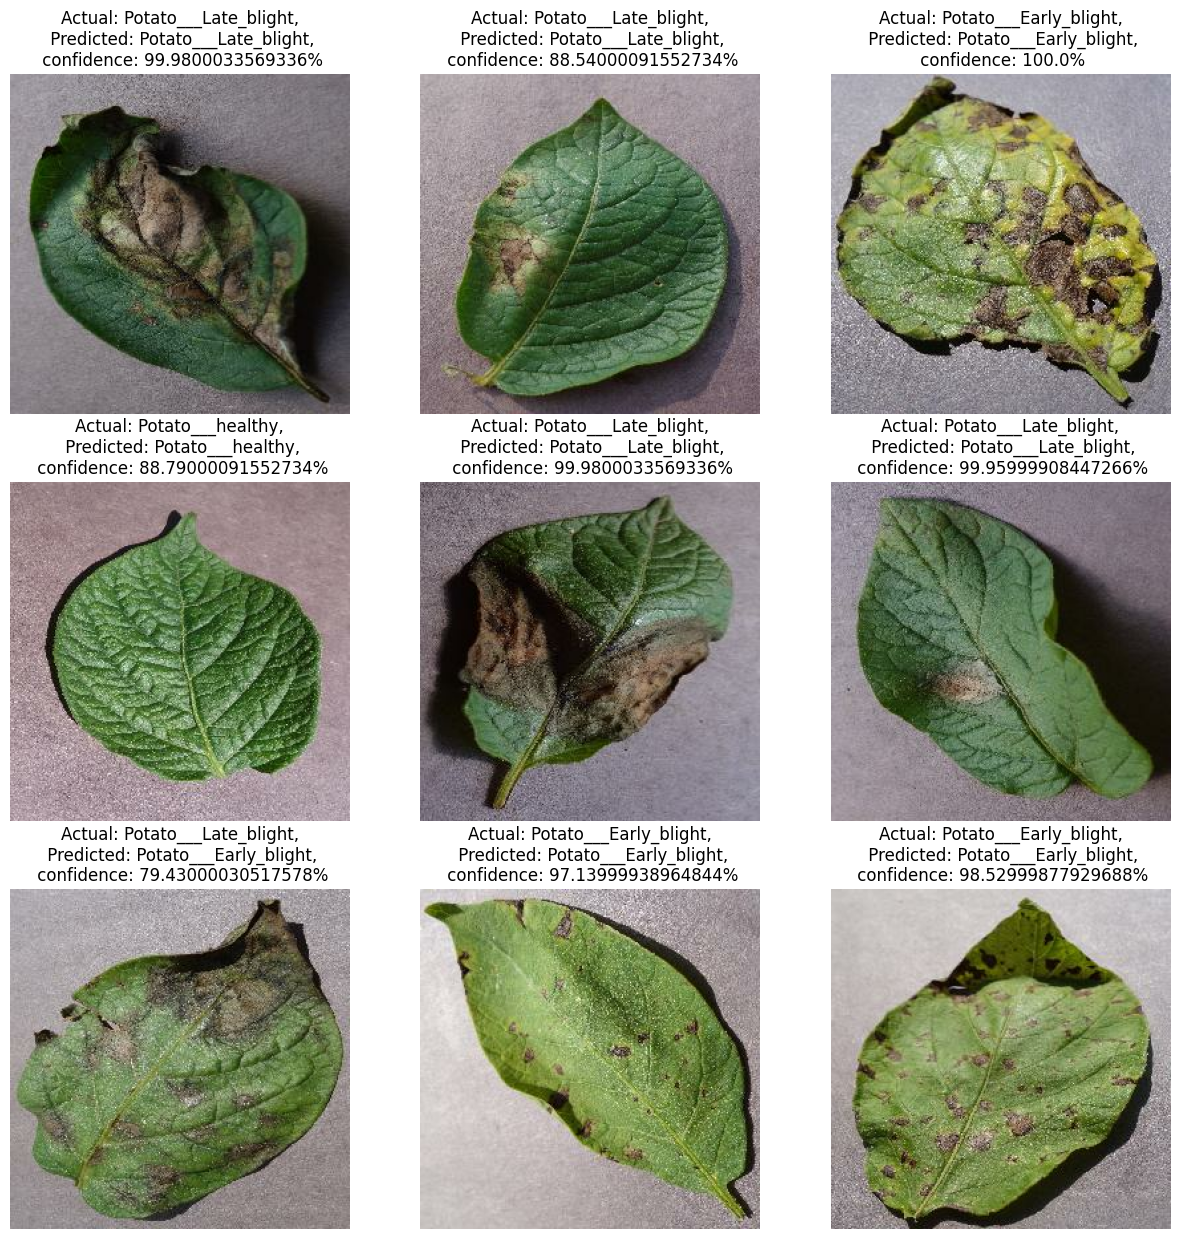

In [24]:
plt.figure(figsize = (15,15))
count = 0
for images, labels in test_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))

        predicteed_class,confidence = predict(model,images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class},\n Predicted: {predicteed_class},\n confidence: {confidence}%")

        plt.axis('off')
        
        if actual_class != predicteed_class:
            count += 1
print(f"number of wrong prediction : {count}")            

Saving model , automaticallt creatinf new model after every run if any chages is made

In [25]:
import os

model_dir = r"C:\Users\user\Desktop\Projects\DL project\Potato_desease\models"

existing_versions = []

for i in os.listdir(model_dir):
    name, ext = os.path.splitext(i)
    if name.isdigit():
        existing_versions.append(int(name))

model_version = max(existing_versions + [0]) + 1

model_path = os.path.join(model_dir, f"{model_version}.keras")

model.save(model_path)

In [26]:
import tensorflow as tf
model = tf.keras.models.load_model("models/1.keras")
print(model.output_shape)   # confirms number of classes

(32, 3)
